In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

#checking gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
#laoding the training labels
df = pd.read_csv("../data/aptos2019-blindness-detection/train.csv")
print(df.head(10))
print(f"\nTotal images: {len(df)}")
print(f"\nClass distribution:")
print(df['diagnosis'].value_counts().sort_index())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
5  0083ee8054ee          4
6  0097f532ac9f          0
7  00a8624548a9          2
8  00b74780d31d          2
9  00cb6555d108          1

Total images: 3662

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


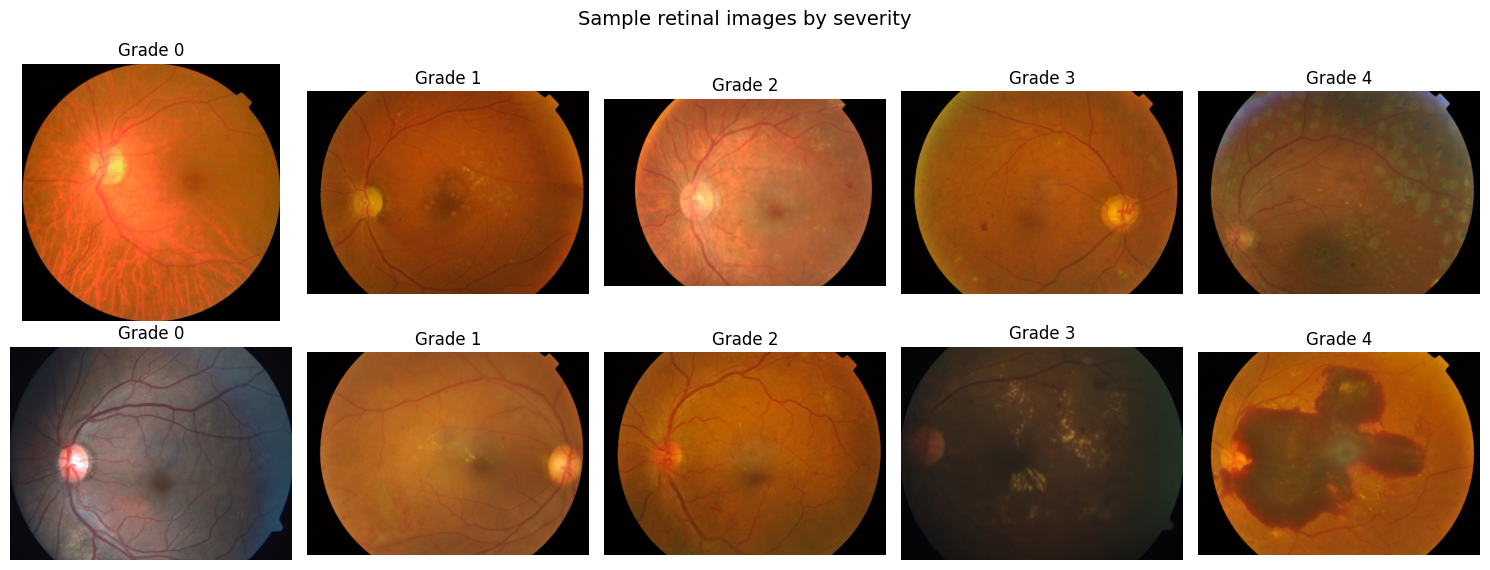

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample retinal images by severity", fontsize=14)

for grade in range(5):
    samples = df[df['diagnosis'] == grade].sample(2, random_state=42)
    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = f"../data/aptos2019-blindness-detection/train_images/{row['id_code']}.png"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i][grade].imshow(img)
        axes[i][grade].set_title(f"Grade {grade}")
        axes[i][grade].axis('off')

plt.tight_layout()
plt.show()

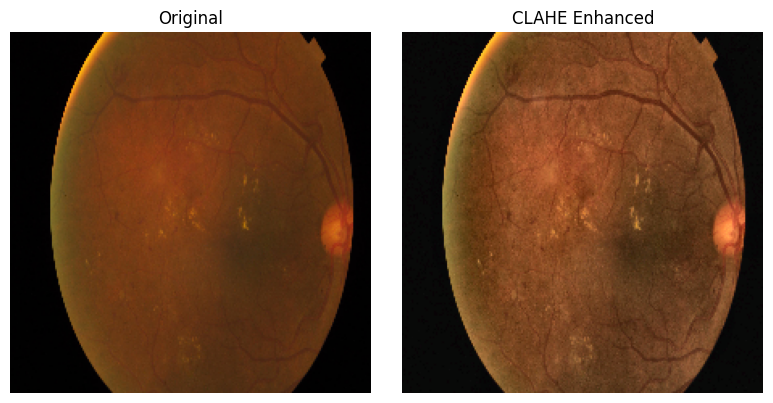

In [5]:
#test
import sys
sys.path.append("..")
from src.preprocessing import apply_clahe

img_path = "../data/aptos2019-blindness-detection/train_images/000c1434d8d7.png"

orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
orig = cv2.resize(orig, (224, 224))
enhanced = apply_clahe(img_path)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(orig)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(enhanced)
axes[1].set_title("CLAHE Enhanced")
axes[1].axis("off")
plt.tight_layout()
plt.show()